In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras import models, layers

In [2]:
# Load the IMDB dataset
print("Loading IMDB dataset...")
num_words = 10_000  # Keep the 10k most frequent tokens

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")
print(f"\nExample of first review (encoded): {train_data[0][:10]}...")
print(f"Label of first review: {train_labels[0]}")

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Test samples: 25000

Example of first review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]...
Label of first review: 1


In [3]:
def vectorize_sequences(sequences, dimension=10000):
    """
    Convert sequences of integers into binary matrices using one-hot encoding.

    Args:
        sequences: List of sequences (lists of integers)
        dimension: Size of the vocabulary (default: 10000)

    Returns:
        Binary matrix of shape (len(sequences), dimension)
    """
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  # Set specific indices of results[i] to 1s
    return results

# Vectorize training and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Convert labels to numpy arrays
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print(f"Vectorized data shape:")
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

Vectorized data shape:
x_train shape: (25000, 10000)
x_test shape: (25000, 10000)


In [4]:
# Set aside 10,000 samples for validation
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print(f"Training set: {partial_x_train.shape[0]} samples")
print(f"Validation set: {x_val.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")


Training set: 15000 samples
Validation set: 10000 samples
Test set: 25000 samples


In [5]:
# Build the model
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.7012 - loss: 0.5974 - val_accuracy: 0.8656 - val_loss: 0.3963
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8924 - loss: 0.3423 - val_accuracy: 0.8809 - val_loss: 0.3179
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9247 - loss: 0.2452 - val_accuracy: 0.8836 - val_loss: 0.2909
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9402 - loss: 0.1944 - val_accuracy: 0.8897 - val_loss: 0.2739
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9547 - loss: 0.1540 - val_accuracy: 0.8844 - val_loss: 0.2830
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9618 - loss: 0.1297 - val_accuracy: 0.8807 - val_loss: 0.3099
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9642 - loss: 0.1143 - val_accuracy: 0.8855 - val_loss: 0.2985
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9726 - loss: 0.0951 - val_accuracy: 0.8831 - 

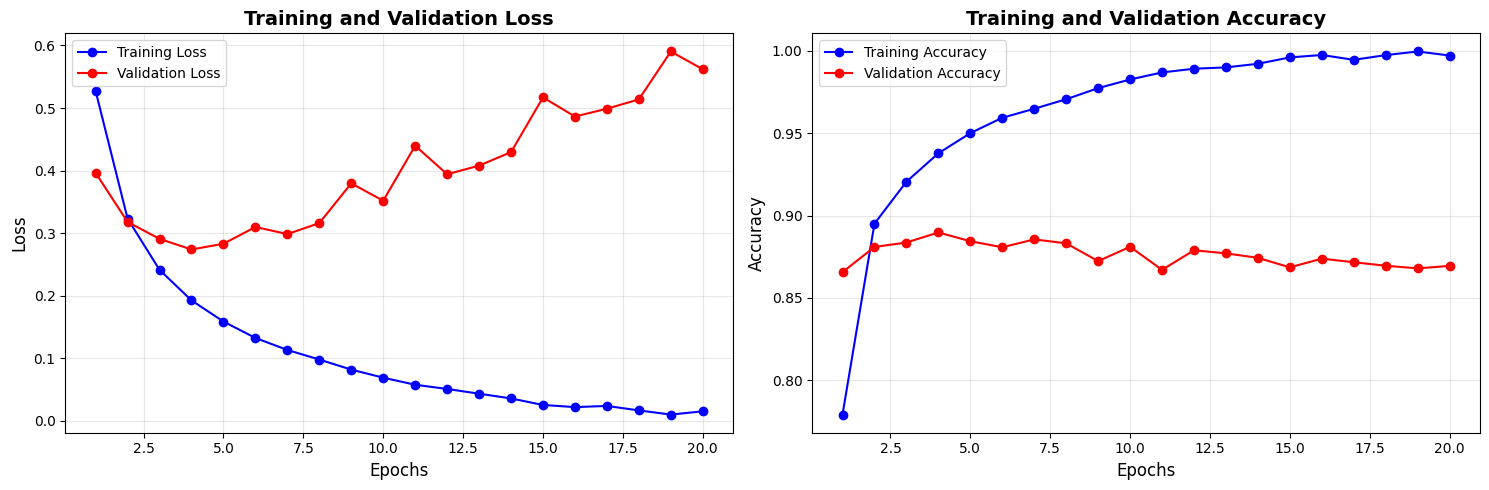

In [7]:
# Extract metrics from history
history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
epochs_range = range(1, len(loss_values) + 1)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(epochs_range, loss_values, 'bo-', label='Training Loss')
ax1.plot(epochs_range, val_loss_values, 'ro-', label='Validation Loss')
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, accuracy, 'bo-', label='Training Accuracy')
ax2.plot(epochs_range, val_accuracy, 'ro-', label='Validation Accuracy')
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Find the epoch with best validation loss
best_epoch = np.argmin(val_loss_values) + 1

print(f"Best validation loss at epoch: {best_epoch}")
print(f"Training loss at epoch {best_epoch}: {loss_values[best_epoch-1]:.4f}")
print(f"Validation loss at epoch {best_epoch}: {val_loss_values[best_epoch-1]:.4f}")
print(f"Training accuracy at epoch {best_epoch}: {accuracy[best_epoch-1]:.4f}")
print(f"Validation accuracy at epoch {best_epoch}: {val_accuracy[best_epoch-1]:.4f}")

Best validation loss at epoch: 4
Training loss at epoch 4: 0.1925
Validation loss at epoch 4: 0.2739
Training accuracy at epoch 4: 0.9378
Validation accuracy at epoch 4: 0.8897


In [9]:
# Build a new model
model_optimal = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_optimal.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train on full training data with optimal epochs
print(f"Retraining model with {best_epoch} epochs...")
history_optimal = model_optimal.fit(
    x_train,
    y_train,
    epochs=best_epoch,
    batch_size=512,
    verbose=1
)

Retraining model with 4 epochs...
Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7339 - loss: 0.5617
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9015 - loss: 0.2868
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9242 - loss: 0.2132
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9410 - loss: 0.1725


In [10]:
# Evaluate on test set
test_loss, test_accuracy = model_optimal.evaluate(x_test, y_test, verbose=0)

print(f"\n{'='*60}")
print("FINAL TEST SET RESULTS")
print('='*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


FINAL TEST SET RESULTS
Test Loss: 0.3057
Test Accuracy: 0.8764 (87.64%)


In [11]:
# Get predictions for first 10 test samples
predictions = model_optimal.predict(x_test[:10])

print("First 10 predictions:")
print("-" * 60)
for i in range(10):
    predicted_sentiment = 'Positive' if predictions[i][0] > 0.5 else 'Negative'
    actual_sentiment = 'Positive' if test_labels[i] == 1 else 'Negative'
    match = '✓' if predicted_sentiment == actual_sentiment else '✗'

    print(f"Review {i+1}: Predicted={predictions[i][0]:.4f} ({predicted_sentiment}) | "
          f"Actual={actual_sentiment} {match}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
First 10 predictions:
------------------------------------------------------------
Review 1: Predicted=0.1752 (Negative) | Actual=Negative ✓
Review 2: Predicted=0.9997 (Positive) | Actual=Positive ✓
Review 3: Predicted=0.6179 (Positive) | Actual=Positive ✓
Review 4: Predicted=0.5582 (Positive) | Actual=Negative ✗
Review 5: Predicted=0.9339 (Positive) | Actual=Positive ✓
Review 6: Predicted=0.5982 (Positive) | Actual=Positive ✓
Review 7: Predicted=0.9981 (Positive) | Actual=Positive ✓
Review 8: Predicted=0.0082 (Negative) | Actual=Negative ✓
Review 9: Predicted=0.9596 (Positive) | Actual=Negative ✗
Review 10: Predicted=0.9702 (Positive) | Actual=Positive ✓
